# EDA del Titanic: El arte de hacer preguntas

El hundimiento del Titanic es uno de los eventos más conocidos en la historia moderna, no solo por su impacto humano sino por la riqueza de datos que dejó detrás. Este dataset contiene variables demográficas, socioeconómicas y familiares de los pasajeros, lo que lo vuelve ideal para practicar en la realización de un EDA.

En este notebook busco entender patrones y relaciones usando preguntas concretas. El objetivo no es hacer todas las gráficas posibles, sino formular preguntas interesantes y responderlas con visualizaciones y cálculos simples, interpretando los resultados en su contexto histórico.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Cargar datos
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
# Vista general
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [55]:
# Resumen estadístico
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Parte 1: Variación

**Pregunta 1:** ¿Cómo se distribuye la edad de los pasajeros? ¿Se observan grupos basados en la edad?

**Pregunta 2:** ¿Cómo se distribuyen las tarifas? ¿Hay valores atípicos?

**Pregunta 3:** ¿Cuál es la proporción de supervivencia?

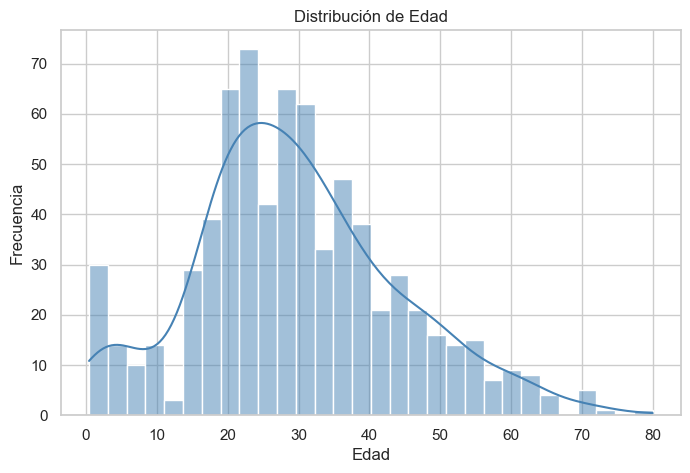

In [56]:
# variable edad
plt.figure(figsize=(8, 5))
sns.histplot(titanic['Age'], bins=30, kde=True, color='steelblue')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

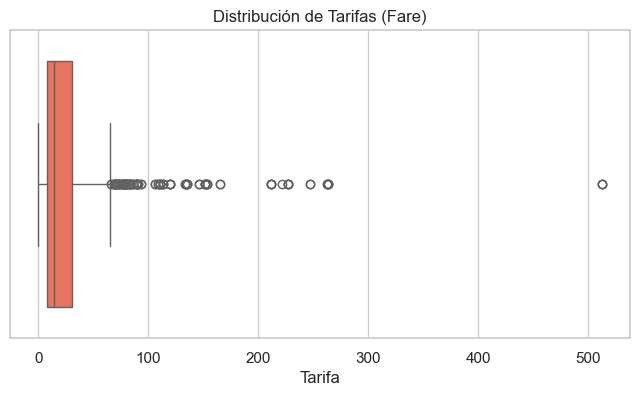

In [57]:
# varriable fare
plt.figure(figsize=(8, 4))
sns.boxplot(x=titanic['Fare'], color='tomato')
plt.title('Distribución de Tarifas (Fare)')
plt.xlabel('Tarifa')
plt.show()

/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_82265/3125093809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_rate.index, y=survival_rate.values, palette='viridis')


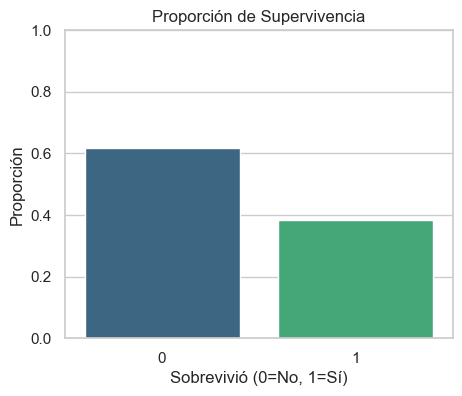

In [58]:
# variable supervivencia
plt.figure(figsize=(5, 4))
survival_rate = titanic['Survived'].value_counts(normalize=True).sort_index()
sns.barplot(x=survival_rate.index, y=survival_rate.values, palette='viridis')
plt.title('Proporción de Supervivencia')
plt.xlabel('Sobrevivió (0=No, 1=Sí)')
plt.ylabel('Proporción')
plt.ylim(0, 1)
plt.show()

**Interpretación:**
- La edad muestra una distribución sesgada con concentración en adultos jóvenes, pero con algunos de niños y adultos mayores. Esto sugiere una mezcla de familias y viajeros individuales.
- Las tarifas presentan una cola larga hacia la derecha: pocos pasajeros pagaron tarifas muy altas, lo que indica alta desigualdad económica en el barco.
- La proporción de supervivencia es menor al 50%, consistente con un evento de alta mortalidad.

**Hipótesis:**
- La desigualdad en tarifas probablemente se asocie con diferencias de clase social y acceso a botes salvavidas.
- La edad podría influir en prioridades de rescate como niños primero.

## Parte 2: Covariación

**Pregunta 1:** ¿La tasa de supervivencia fue diferente entre clases sociales?

**Pregunta 2:** ¿Cómo interactúan sexo y clase con la supervivencia?

**Pregunta 3:** ¿Los pasajeros más jóvenes tenían mayor probabilidad de sobrevivir?

/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_82265/457027617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_by_class, x='Pclass', y='Survived', palette='crest')


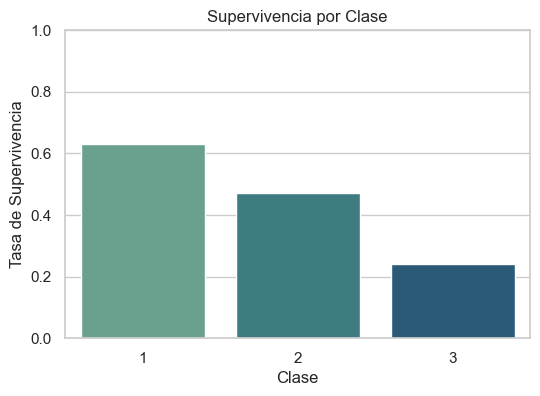

In [59]:
plt.figure(figsize=(6, 4))
survival_by_class = titanic.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(data=survival_by_class, x='Pclass', y='Survived', palette='crest')
plt.title('Supervivencia por Clase')
plt.xlabel('Clase')
plt.ylabel('Tasa de Supervivencia')
plt.ylim(0, 1)
plt.show()

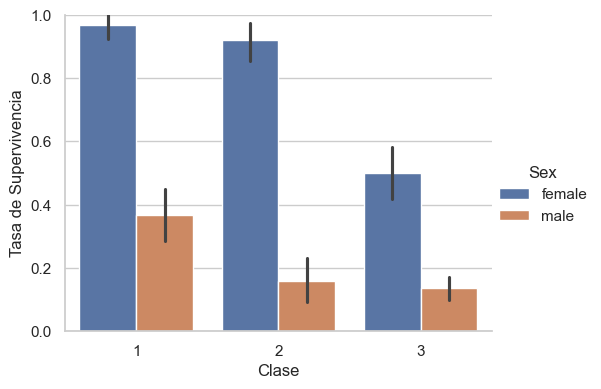

In [60]:
g = sns.catplot(
    data=titanic,
    x='Pclass',
    y='Survived',
    hue='Sex',
    kind='bar',
    height=4,
    aspect=1.3
)
g.set_titles('Supervivencia por Clase y Sexo')
g.set_axis_labels('Clase', 'Tasa de Supervivencia')
plt.ylim(0, 1)
plt.show()

/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_82265/738617146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x='Survived', y='Age', palette='Set2')


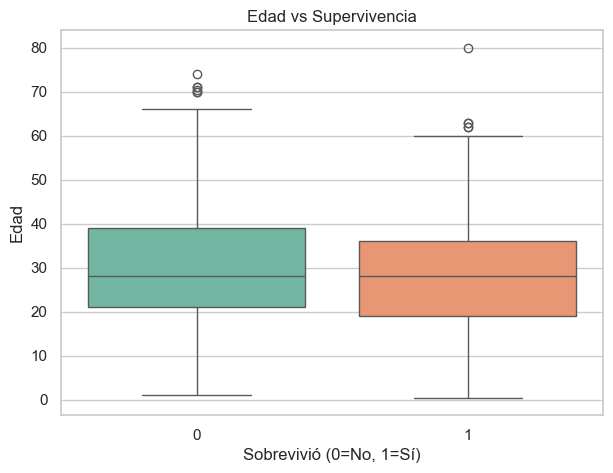

In [61]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=titanic, x='Survived', y='Age', palette='Set2')
plt.title('Edad vs Supervivencia')
plt.xlabel('Sobrevivió (0=No, 1=Sí)')
plt.ylabel('Edad')
plt.show()

**Interpretación:**
- La supervivencia aumenta claramente con la clase social: primera clase tiene mayor tasa que tercera.
- Las mujeres sobreviven más en todas las clases, lo que apoya la idea de que se priorizaron mujeres y niños en la evacuación.
- La distribución de edades sugiere ligeramente que los sobrevivientes tienden a ser ligeramente más jóvenes, aunque hay traslape importante.

**Conexión histórica:**
- El acceso a botes y la ubicación de cabinas probablemente favoreció a pasajeros de primera clase.
- Normas sociales de la época pueden explicar la prioridad dada a mujeres y niños.

## Parte 3: Valores Faltantes

**Preguntas:**
- ¿Qué variables tienen valores faltantes?
- ¿Los valores faltantes siguen un patrón?
- ¿Cómo manejar estos valores faltantes?

In [62]:
# Conteo de valores faltantes
titanic.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

**Interpretación:**
- Es típico que variables como Age y Cabin tengan faltantes, Cabin suele ser el más incompleto.
- Si los faltantes se concentran en ciertas clases o tipos de pasajero, podrían no ser aleatorios.

**Propuesta:**
- Age: imputación con mediana por clase/sexo para respetar estructura social.
- Cabin: podría descartarse o convertirse en indicador binario (tiene/no tiene cabina).
- Documentar el sesgo potencial si los faltantes no son aleatorios.

## Parte 4: Pregunta original

**Pregunta:** ¿Compartir el mismo ticket se relaciona con la supervivencia, y cambia ese efecto según la clase social?

/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_82265/1130749963.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='TicketGroupCategory', y='Survived', palette='rocket')


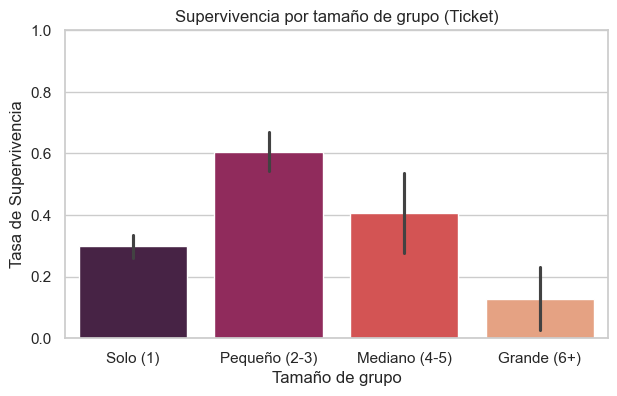

In [63]:
# Tamaño de grupo por Ticket
titanic['TicketGroupSize'] = titanic.groupby('Ticket')['Ticket'].transform('count')
titanic['TicketGroupCategory'] = pd.cut(
    titanic['TicketGroupSize'],
    bins=[0, 1, 3, 5, 11],
    labels=['Solo (1)', 'Pequeño (2-3)', 'Mediano (4-5)', 'Grande (6+)']
 )

plt.figure(figsize=(7, 4))
sns.barplot(data=titanic, x='TicketGroupCategory', y='Survived', palette='rocket')
plt.title('Supervivencia por tamaño de grupo (Ticket)')
plt.xlabel('Tamaño de grupo')
plt.ylabel('Tasa de Supervivencia')
plt.ylim(0, 1)
plt.show()

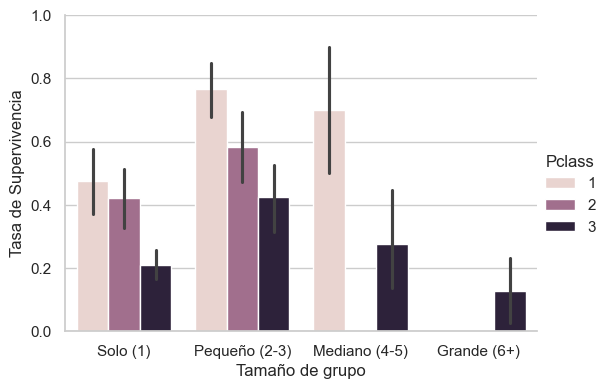

In [64]:
g = sns.catplot(
    data=titanic,
    x='TicketGroupCategory',
    y='Survived',
    hue='Pclass',
    kind='bar',
    height=4,
    aspect=1.4
)
g.set_titles('Supervivencia por tamaño de grupo y clase')
g.set_axis_labels('Tamaño de grupo', 'Tasa de Supervivencia')
plt.ylim(0, 1)
plt.show()

**Conclusiones:**
- Los grupos grandes por ticket muestran patrones de supervivencia distintos a quienes viajaban solos, lo que sugiere que el tamaño del grupo pudo influir en el acceso a información o en la capacidad de mantenerse juntos.
- Al separar por clase, el efecto se modula: en primera clase la supervivencia se mantiene alta en casi todos los tamaños, mientras que en tercera clase los grupos grandes tienden a tener tasas más bajas.

Esto infiere que el tamaño del grupo por ticket se relaciona con la clase social y no actúa de forma aislada.

## Reflexión final

Lo más difícil del EDA fue definir las preguntas que realmente aportaban algo a la narrativa y cómo interpretar patrones sin sobreexplicar. Muchas relaciones son plausibles pero no necesariamente causales, y fue importante distinguir entre correlación y explicación histórica. Aprendí que el EDA es un proceso iterativo, ya que cada hallazgo genera nuevas preguntas. También noté que los valores faltantes no son solo un problema técnico, sino una señal del proceso social y económico que produjo el dataset.